In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('/content/traffic.csv')

In [2]:
df.shape

(23588, 9)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23588 entries, 0 to 23587
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   event    23588 non-null  object
 1   date     23588 non-null  object
 2   country  23587 non-null  object
 3   city     23587 non-null  object
 4   artist   23584 non-null  object
 5   album    23587 non-null  object
 6   track    23587 non-null  object
 7   isrc     22638 non-null  object
 8   linkid   23588 non-null  object
dtypes: object(9)
memory usage: 1.6+ MB


In [4]:
df.isnull().sum()

,0
event,0
date,0
country,1
city,1
artist,4
album,1
track,1
isrc,950
linkid,0


In [5]:
df['date'] = pd.to_datetime(
    df['date'],
    dayfirst=True
)

/tmp/ipykernel_9453/2301042787.py:1: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['date'] = pd.to_datetime(


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23588 entries, 0 to 23587
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   event    23588 non-null  object        
 1   date     23588 non-null  datetime64[ns]
 2   country  23587 non-null  object        
 3   city     23587 non-null  object        
 4   artist   23584 non-null  object        
 5   album    23587 non-null  object        
 6   track    23587 non-null  object        
 7   isrc     22638 non-null  object        
 8   linkid   23588 non-null  object        
dtypes: datetime64[ns](1), object(8)
memory usage: 1.6+ MB


In [8]:
country_traffic = df.groupby(
    'country'
)['event'].count().sort_values(
    ascending=False
)

country_traffic.head(10)

,event
country,
India,4860
Saudi Arabia,4082
United States,4007
France,1700
Iraq,750
Pakistan,686
United Kingdom,593
Germany,554
Canada,392


In [9]:
artist_traffic = df.groupby(
    'artist'
)['event'].count().sort_values(
    ascending=False
)

artist_traffic.head(10)

,event
artist,
Tesher,4036
Anne-Marie,929
Tundra Beats,909
"DMNDS, Strange Fruits Music, Fallen Roses, Lujavo, Nito-Onna",666
"Surf Mesa, Emilee",657
"Shawn Mendes, Tainy",579
Roddy Ricch,572
Reyanna Maria,503
"50 Cent, Olivia",481


In [10]:
daily_traffic = df.groupby(
    'date'
)['event'].count()

daily_traffic.head()

,event
date,
2021-08-19,3895
2021-08-20,3563
2021-08-21,3328
2021-08-22,3342
2021-08-23,3165


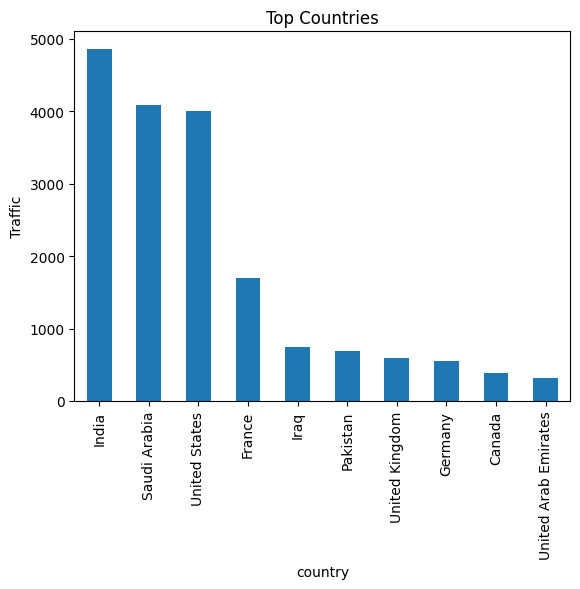

In [11]:
country_traffic.head(10).plot(
    kind='bar'
)

plt.title('Top Countries')
plt.ylabel('Traffic')
plt.show()

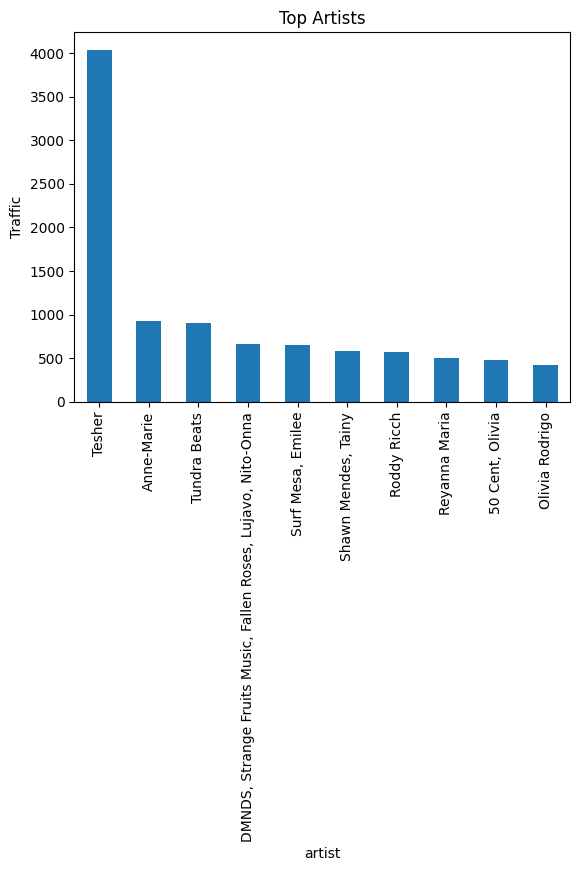

In [12]:
artist_traffic.head(10).plot(
    kind='bar'
)

plt.title('Top Artists')
plt.ylabel('Traffic')
plt.show()

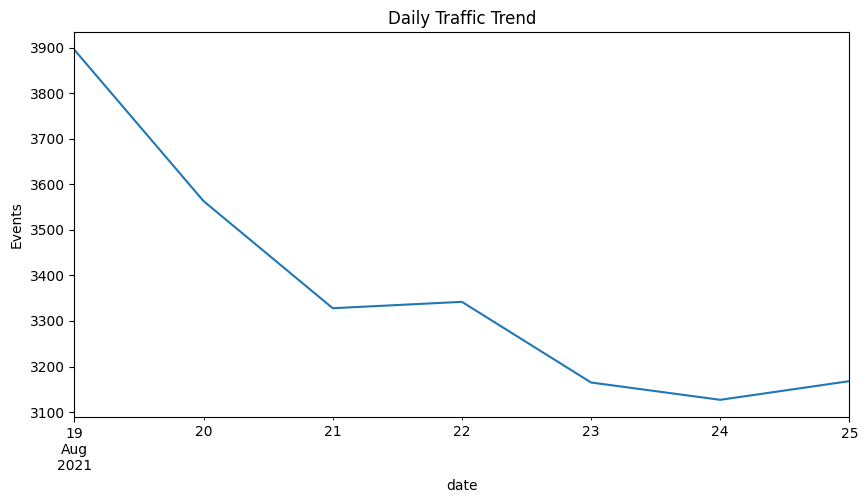

In [13]:
daily_traffic.plot(
    kind='line',
    figsize=(10,5)
)

plt.title('Daily Traffic Trend')
plt.ylabel('Events')
plt.show()

Key findings                                 
Traffic Overview
Dataset contains 23,588 events.
Very few missing values except for ISRC (950 missing) and a handful in artist/country/city.
Date column successfully converted to datetime.
Top Countries
India — 4,860 events
Saudi Arabia — 4,082 events
United States — 4,007 events

These three countries alone contribute a major share of traffic.

Top Artists
Tesher dominates traffic with 4,036 events.
Anne-Marie and Tundra Beats follow far behind.

This suggests users are highly concentrated around a few popular artists/tracks.

Daily Traffic Trend

Traffic peaks around:

Aug 19: 3,895 events
Aug 20: 3,563 events